# Create, Cluster, and Analyze Baseline Networks

## Purpose: 

* Load data from all iterations and parameter combinations
* Create baseline networks (each parameter combination is run with `seed=1000` for `Louvain clustering`) 
* Run `GO` analysis on all of the above clusters. 
* Save baseline networks, clusters, and GO results 

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

import glob, pickle, networkx, os
import seaborn as sns
import matplotlib.pyplot as plt

from goatools.obo_parser import GODag
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS
from goatools.base import download_go_basic_obo

## Load Data from Files into Data Structures

In [2]:
# use string manipulation to pull out parameter combinations

parameter_combinations = [file.split("/")[-1].split(".")[0] for file in sorted(glob.glob("/home/jve4pt/RBFOX2-Mouse-Embryonic-Heart-Analysis/outputs/pickled_networks/differential_expression_tf_networks/*", recursive=True))]

parameter_combinations

['upstream_2500_score_900',
 'upstream_2500_score_950',
 'upstream_2500_score_990',
 'upstream_5000_score_900',
 'upstream_5000_score_950',
 'upstream_5000_score_990',
 'upstream_750_score_900',
 'upstream_750_score_950',
 'upstream_750_score_990']

In [9]:
meta_GO_df = pd.read_csv("../../../../outputs/gene_ontology_analysis/differential_expression_networks/all_GO_analyses.tsv.gz", sep="\t", compression="gzip")

# subset to Biological Process 
meta_GO_df = meta_GO_df[meta_GO_df["NS"]=="BP"]

meta_GO_df.index.size
meta_GO_df.head()

meta_GO_df["name"].value_counts()

83635

,# GO,NS,enrichment,name,ratio_in_study,ratio_in_pop,p_uncorrected,depth,study_count,p_fdr_bh,study_items,Parameter_Combination,Iteration,Cluster
6,GO:0045893,BP,e,positive regulation of DNA-templated transcription,11/60,702/21965,0.000003,9,11,0.034201,"apoe, fzd7, hmbox1, maz, mef2a, npas4, sox4, tbx2, tbx3, tmsb4x, wnt4",upstream_2500_score_900,1,cluster_5
7,GO:0007275,BP,e,multicellular organism development,13/60,1090/21965,0.000006,3,13,0.038170,"crb2, efnb1, fgfr4, fst, fzd7, hic1, hoxb5, mef2a, reln, tbx2, tbx3, wnt2, wnt4",upstream_2500_score_900,1,cluster_5
8,GO:0042157,BP,e,lipoprotein metabolic process,3/60,18/21965,0.000015,5,3,0.046304,"apoe, apom, pcsk9",upstream_2500_score_900,1,cluster_5
9,GO:0051145,BP,e,smooth muscle cell differentiation,3/60,20/21965,0.000021,5,3,0.046304,"tbx2, tbx3, wnt4",upstream_2500_score_900,1,cluster_5
10,GO:0072105,BP,e,ureteric peristalsis,2/60,3/21965,0.000022,8,2,0.046304,"tbx2, tbx3",upstream_2500_score_900,1,cluster_5


cholesterol metabolic process                                                                                                         4080
multicellular organism development                                                                                                    2835
cholesterol homeostasis                                                                                                               2522
steroid metabolic process                                                                                                             2403
lipoprotein metabolic process                                                                                                         2156
positive regulation of TRAIL-activated apoptotic signaling pathway                                                                    2082
sterol biosynthetic process                                                                                                           1987
canonical Wnt signaling pat

In [5]:
# load the pickled louvain community clustering results 
# which is a dict organized by parameter combination, then iteration, then cluster id

louvain_results = pickle.load(open("../../../../outputs/louvain_clustering/differential_expression_networks/all_louvain_clusterings.pkl", 'rb'))

## Plot Distribution of Number of Clusters per 1000 Iterations for Parameter Combinations

See plot below. 

,Number of Clusters,Parameter Combination
0,14,2500-900
1,13,2500-900
2,14,2500-900
3,11,2500-900
4,12,2500-900


<Figure size 900x600 with 0 Axes>

Text(0.5, 1.0, 'Number of Clusters per Parameter Combination')

<AxesSubplot:title={'center':'Number of Clusters per Parameter Combination'}, xlabel='Parameter Combination', ylabel='Number of Clusters'>

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, '2500-900'),
  Text(1, 0, '2500-950'),
  Text(2, 0, '2500-990'),
  Text(3, 0, '5000-900'),
  Text(4, 0, '5000-950'),
  Text(5, 0, '5000-990'),
  Text(6, 0, '750-900'),
  Text(7, 0, '750-950'),
  Text(8, 0, '750-990')])

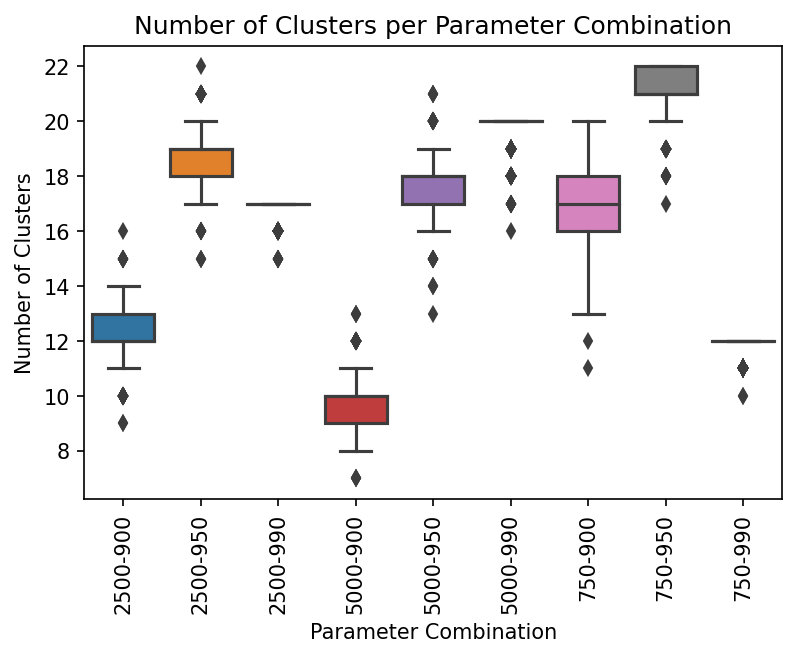

In [6]:
# df that we're going to concat into
plotter_df = pd.DataFrame(columns = ["Number of Clusters", "Parameter Combination"]) 

# for every parameter combination and their iterations 
# append the number of clusters to a df which is used
# to plot the distributions of clusters found across
# 1000 iterations for each parameter combination

# NOTE: see graph below 

for parameter_combination in louvain_results:
    
    num_clusters = []
    
    for iteration in louvain_results[parameter_combination]: 
        
        num_clusters.append(len(louvain_results[parameter_combination][iteration]))
        
    tmp = pd.DataFrame()
    tmp["Number of Clusters"] = num_clusters 
    tmp["Parameter Combination"] = ["-".join(parameter_combination.split("_")[i] for i in [1,3])]*len(louvain_results[parameter_combination])
    
    plotter_df = pd.concat([plotter_df, tmp])

plotter_df.head()

plt.figure(dpi = 150)

plt.title("Number of Clusters per Parameter Combination")

sns.boxplot(data=plotter_df, x="Parameter Combination", y="Number of Clusters")

plt.xticks(rotation=90)

In [10]:
# create pandas dataframe that joins all Gene Ontology names with a comma 
# for a given iteration and parameter combination

def calculate_number_of_unique_clusters(df): 
    """
    Find out the number of iterations across all parameter combinations 
    where any significant GO term is only enriched in 1 cluster.
    
    This would be as opposed to the same GO Term showing up multiple times
    within the same iteration
    """
    
    return df["name"].duplicated().any()
    
    
iteration_specific_GO_terms = meta_GO_df[["name", "Parameter_Combination", "Iteration", "Cluster"]].groupby(["Parameter_Combination", "Iteration"]).apply(calculate_number_of_unique_clusters)


<Figure size 600x400 with 0 Axes>

Text(0.5, 0.98, 'For any possible iteration/parameter combination, \nare significant GO terms only found in one cluster (unique)?')

([<matplotlib.patches.Wedge at 0x7f79b9a598e0>,
 [Text(-1.0308079190871127, 0.3839726994817429, 'False'),
  Text(1.0308079370621706, -0.38397265122614177, 'True')],
 [Text(-0.5622588649566068, 0.20943965426276884, '89%'),
  Text(0.5622588747611839, -0.20943962794153184, '11%')])

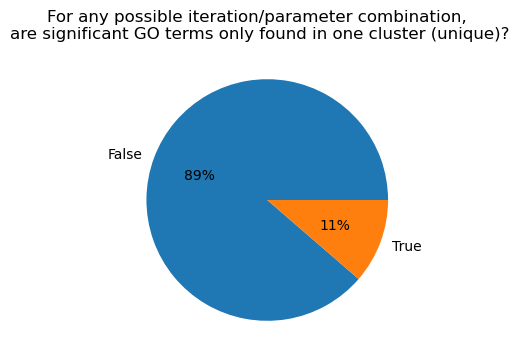

In [11]:
plt.figure(dpi = 100)

plt.suptitle("For any possible iteration/parameter combination, \nare significant GO terms only found in one cluster (unique)?")

plt.pie(iteration_specific_GO_terms.value_counts(), labels=iteration_specific_GO_terms.value_counts().index, autopct="%.0f%%" )

## Create Baseline Networks & Run GO Analysis on Them

Used for comparison downstream

In [12]:
baseline_networks = {}

for file in sorted(glob.glob("/home/jve4pt/RBFOX2-Mouse-Embryonic-Heart-Analysis/outputs/pickled_networks/differential_expression_tf_networks/*", recursive=True)): 
    
    parameter_combination = file.split("/")[-1].split(".")[0]
    
    baseline_networks[parameter_combination] = pickle.load(open(file, "rb"))
    
baseline_networks_clustering = {}

for parameter_combination in parameter_combinations: 
    baseline_networks_clustering[parameter_combination] = networkx.community.louvain_communities(baseline_networks[parameter_combination], seed=1000)

    

In [ ]:
# file for population (protein-coding genes)
protein_coding_genes = []

# file for gene ontology associations
associations = pickle.load(open("/home/jve4pt/RBFOX2-Mouse-Embryonic-Heart-Analysis/inputs/goatools_input/mouse/gene_ontology_associations.pkl", 'rb'))

with open("/home/jve4pt/RBFOX2-Mouse-Embryonic-Heart-Analysis/inputs/goatools_input/population.txt", 'r') as in_file: 
    for line in in_file: 
        protein_coding_genes.append(line.strip("\n"))
        
download_go_basic_obo()
        
# initialize object with population, associations, and GO DAG
enrichment_analysis_obj = GOEnrichmentStudyNS(
    
    protein_coding_genes,
    associations, 
    GODag("go-basic.obo"), 

    # not propagating counts to parents of GO terms 
    propagate_counts = False, 
    methods = ["fdr_bh"]

)

""" 
for each parameter combination, we are saving 
the GO results for each cluster
"""

baseline_networks_GO = {}

for parameter_combination in parameter_combinations: 
    
    baseline_networks_GO[parameter_combination] = {}
    
    for count, genes in enumerate(baseline_networks_clustering[parameter_combination]):

        # run analysis
        results = enrichment_analysis_obj.run_study(genes)
        
        results = [r for r in results if r.p_fdr_bh < 0.05]
        
        baseline_networks_GO[parameter_combination][count] = results 

os.remove("go-basic.obo")

$ get http://purl.obolibrary.org/obo/go/go-basic.obo
requests.get(http://purl.obolibrary.org/obo/go/go-basic.obo, stream=True)
  WROTE: go-basic.obo



'go-basic.obo'

go-basic.obo: fmt(1.2) rel(2023-10-09) 46,296 Terms

Load BP Ontology Enrichment Analysis ...
 85% 18,620 of 21,965 population items found in association

Load CC Ontology Enrichment Analysis ...
 85% 18,761 of 21,965 population items found in association

Load MF Ontology Enrichment Analysis ...
 85% 18,703 of 21,965 population items found in association


' \nfor each parameter combination, we are saving \nthe GO results for each cluster\n'


Runing BP Ontology Analysis: current study set of 9 IDs.
 89%      8 of      9 study items found in association
100%      9 of      9 study items found in population(21965)
Calculating 12,610 uncorrected p-values using fisher_scipy_stats
  12,610 terms are associated with 18,620 of 21,965 population items
     143 terms are associated with      8 of      9 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC Ontology Analysis: current study set of 9 IDs.
100%      9 of      9 study items found in association
100%      9 of      9 study items found in population(21965)
Calculating 1,815 uncorrected p-values using fisher_scipy_stats
   1,815 terms are associated with 18,761 of 21,965 population items
      36 terms are associated with      9 of      9 study items
  MET

## Output GO Results & Louvain Results

In [ ]:
for parameter_combination in baseline_networks_GO: 
    for cluster in baseline_networks_GO[parameter_combination]: 
        enrichment_analysis_obj.wr_tsv(
            "{}-cluster_{}.tsv".format(parameter_combination, cluster),
            baseline_networks_GO[parameter_combination][cluster]
        )

In [ ]:
pickle.dump(baseline_networks_clustering, open("../../../../outputs/louvain_clustering/differential_expression_networks/baseline_network_louvain_clustering.pkl", 'wb'))

In [ ]:

# dataframe with all baseline network Gene Ontology analysis results in one
baseline_GO_df = pd.DataFrame()

"""
for GO results for all parameter combinations and clusters,  
retrieve them via `glob`, subset to FDR p < 0.05, 
save info about parameter combination and cluster
and finally concatenate all these together

# OPTIONAL: filtering GO terms by keywords

"""

for file in glob.glob("*.tsv"): 

    cluster = file.split("-")[-1].split(".")[0]
    parameter_combination = file.split("-")[0]

    df = pd.read_csv(file , sep="\t")

    df = df[df["p_fdr_bh"]<0.05].copy()
    
    if df.index.size>0:

        df["Parameter_Combination"] = parameter_combination
        df["Cluster"] = cluster

        baseline_GO_df = pd.concat([meta_GO_df, df])

In [ ]:
baseline_GO_df.index.size 
baseline_GO_df.head()

In [ ]:
meta_GO_df.to_csv(
    "../../../../outputs/gene_ontology_analysis/differential_expression_networks/baseline_networks_GO.tsv.gz", 
    sep="\t", 
    compression='gzip', 
    index=False
)

In [ ]:
baseline_GO_df = pd.read_csv(
    "../../../../outputs/gene_ontology_analysis/differential_expression_networks/baseline_networks_GO.tsv.gz", 
    sep="\t", 
    compression="gzip", 

)

In [ ]:
base

Remove the multiple individual files in this directory now that they've been combined. 

In [ ]:
for file in glob.glob("*.tsv"): 
    os.remove(file)